In [45]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np
import glob
import pytz
import os
from sklearn.model_selection import train_test_split
from collections import Counter
import numpy as np
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
from imblearn.pipeline import Pipeline as ImbPipeline
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import GridSearchCV
from scipy.signal import butter, filtfilt
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import classification_report, confusion_matrix

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else ("mps" if torch.backends.mps.is_available() else "cpu")
)
print(f"Using device: {device}")

Using device: mps


In [2]:
EVENTS_FOLDER = '../../data/bishkek_csr/03_train_ready/event_exports' 
RESPECK_FOLDER = '../../data/bishkek_csr/03_train_ready/respeck'
NASAL_FOLDER = '../../data/bishkek_csr/03_train_ready/nasal_files'
FEATURES_FOLDER = '../../data/bishkek_csr/03_train_ready/respeck_features'
# --- Define relevant events ---

APNEA_EVENT_LABELS = [
    'Obstructive Apnea', 
]

all_sessions_df_list = []
event_files = glob.glob(os.path.join(EVENTS_FOLDER, '*_event_export.csv'))

if not event_files:
    raise FileNotFoundError(f"No event files found in '{EVENTS_FOLDER}'.")

print(f"Found {len(event_files)} event files. Processing each one...")

for event_file_path in event_files:
    # --- 1. Setup paths and IDs ---
    base_name = os.path.basename(event_file_path)
    session_id = base_name.split('_event_export.csv')[0]
    respeck_file_path = os.path.join(RESPECK_FOLDER, f'{session_id}_respeck.csv')
    nasal_file_path = os.path.join(NASAL_FOLDER, f'{session_id}_nasal.csv')
    feature_file_path = os.path.join(FEATURES_FOLDER, f'{session_id}_respeck_features.csv')
    
    if not all(os.path.exists(p) for p in [respeck_file_path, nasal_file_path, feature_file_path]):
        print(f"  - WARNING: Skipping session '{session_id}'. A corresponding file is missing.")
        continue
    print(f"  - Processing session: {session_id}")
    
    # --- 2. Load all data sources ---
    df_events = pd.read_csv(event_file_path, decimal=',')
    df_nasal = pd.read_csv(nasal_file_path)
    df_respeck = pd.read_csv(respeck_file_path)
    df_features = pd.read_csv(feature_file_path)

    # --- 3. Standardize timestamp columns and types ---
    df_events.rename(columns={'UnixTimestamp': 'timestamp_unix'}, inplace=True)
    df_nasal.rename(columns={'UnixTimestamp': 'timestamp_unix'}, inplace=True, errors='ignore')
    df_respeck.rename(columns={'alignedTimestamp': 'timestamp_unix'}, inplace=True)
    
    df_features['timestamp_unix'] = pd.to_datetime(df_features['startTimestamp'], format="mixed")
    df_features['timestamp_unix'] = df_features['timestamp_unix'].astype('int64') // 10**6

    df_features['timestamp_unix_end'] = pd.to_datetime(df_features['endTimestamp'], format="mixed")
    df_features['timestamp_unix_end'] = df_features['timestamp_unix_end'].astype('int64') // 10**6
    
    for df_ in [df_events, df_nasal, df_respeck]:
        df_['timestamp_unix'] = pd.to_numeric(df_['timestamp_unix'], errors='coerce')
        df_.dropna(subset=['timestamp_unix'], inplace=True)
        df_['timestamp_unix'] = df_['timestamp_unix'].astype('int64')

    # --- 4. Calculate the true overlapping time range ---
    start_time = max(df_nasal['timestamp_unix'].min(), df_respeck['timestamp_unix'].min())
    end_time = min(df_nasal['timestamp_unix'].max(), df_respeck['timestamp_unix'].max())
    
    # --- 5. Trim Respeck data to the overlapping time range ---
    df_respeck = df_respeck[(df_respeck['timestamp_unix'] >= start_time) & (df_respeck['timestamp_unix'] <= end_time)].copy()

    if df_respeck.empty:
        print(f"  - WARNING: Skipping session '{session_id}'. No Respeck data in the overlapping range.")
        continue

    if df_respeck['breathingSignal'].isnull().any():
        print("  - Imputing NaNs in raw breathing signal...")
        df_respeck['breathingSignal'] = df_respeck['breathingSignal'].ffill().bfill()

    # =========================================================================
    # --- 5b. NEW: APPLY BANDPASS FILTER TO THE BREATHING SIGNAL ---
    print("  - Applying bandpass filter to breathing signal...")
    df_respeck = df_respeck.sort_values('timestamp_unix').reset_index(drop=True)
    
    time_diffs_ms = df_respeck['timestamp_unix'].diff().dropna()
    if time_diffs_ms.empty or time_diffs_ms.median() == 0:
        print(f"  - WARNING: Skipping session '{session_id}'. Cannot determine sampling rate.")
        continue
    
    fs = 1.0 / (time_diffs_ms.median() / 1000.0)
    print(f"    - Calculated sampling rate: {fs:.2f} Hz")

    lowcut, highcut = 0.1, 1.5
    
    try:
        nyquist = 0.5 * fs
        b, a = butter(2, [lowcut/nyquist, highcut/nyquist], btype='band')
        df_respeck['filteredBreathingSignal'] = filtfilt(b, a, df_respeck['breathingSignal'])
    except ValueError as e:
        print(f"  - WARNING: Skipping session '{session_id}'. Filter error: {e}")
        continue
    # =========================================================================

    print("  - Preparing and merging engineered features using Unix time intervals...")
    df_respeck = df_respeck.sort_values('timestamp_unix')
    df_features = df_features.sort_values('timestamp_unix')

    # Use merge_asof to find the correct feature window for each respeck data point
    df_session_merged = pd.merge_asof(
        df_respeck,
        df_features,
        on='timestamp_unix',
        direction='backward' # Finds the last feature window that started <= the respeck timestamp
    )

    cols_to_drop = ['Unnamed: 0','startTimestamp', 'endTimestamp', 'timestamp_unix_end']
    df_session_merged.drop(columns=cols_to_drop, inplace=True, errors='ignore')

    if df_session_merged.empty:
        print(f"  - WARNING: Skipping session '{session_id}'. No merge matches found.")
        continue
        
    # --- 6. **NEW: Precise Interval-Based Labeling using Duration** ---
    print(f"  - Applying precise interval-based labels...")
    
    # ** Step 6a: Initialize the label column in the respeck data with 0 (Normal)
    df_session_merged['Label'] = 0
    
    # ** Step 6b: Calculate event end times using the 'Duration' column
    # The 'Duration' column has commas, which we handled with `decimal=','` at load time.
    # Convert duration from seconds to milliseconds to match the Unix timestamps.
    df_events['Duration_ms'] = (df_events['Duration'] * 1000).astype('int64')
    df_events['end_time_unix'] = df_events['timestamp_unix'] + df_events['Duration_ms']
    
    # ** Step 6c: Filter for only the apnea/hypopnea events we want to label as '1'
    df_apnea_events = df_events[df_events['Event'].isin(APNEA_EVENT_LABELS)].copy()

    # ** Step 6d: Efficiently label the respeck data using event intervals
    # This is much faster than looping. It checks which respeck timestamps fall
    # within any of the [start, end] intervals of the apnea events.
    for index, event in df_apnea_events.iterrows():
        start_event = event['timestamp_unix']
        end_event = event['end_time_unix']
        # Set the 'Label' to 1 for all respeck rows within this event's time interval
        df_session_merged.loc[df_session_merged['timestamp_unix'].between(start_event, end_event), 'Label'] = 1

    # --- 7. Finalize session data ---
    df_session_merged['SessionID'] = session_id
    all_sessions_df_list.append(df_session_merged)

# --- Combine all nights and perform final processing ---
if not all_sessions_df_list:
    raise ValueError("Processing failed. No data was loaded.")

df = pd.concat(all_sessions_df_list, ignore_index=True)


df.to_csv('test.csv')
print("\n----------------------------------------------------")
print("Data loading with PRECISE interval labeling complete.")
print(f"Final DataFrame shape: {df.shape}")
print(f"Final class distribution in raw data: \n{df['Label'].value_counts(normalize=True)}")

Found 9 event files. Processing each one...
  - Processing session: 26-04-2025
  - Imputing NaNs in raw breathing signal...
  - Applying bandpass filter to breathing signal...
    - Calculated sampling rate: 12.50 Hz
  - Preparing and merging engineered features using Unix time intervals...
  - Applying precise interval-based labels...
  - Processing session: 08-05-2025
  - Imputing NaNs in raw breathing signal...
  - Applying bandpass filter to breathing signal...
    - Calculated sampling rate: 12.50 Hz
  - Preparing and merging engineered features using Unix time intervals...
  - Applying precise interval-based labels...
  - Processing session: 05-04-2025
  - Imputing NaNs in raw breathing signal...
  - Applying bandpass filter to breathing signal...
    - Calculated sampling rate: 12.50 Hz
  - Preparing and merging engineered features using Unix time intervals...
  - Applying precise interval-based labels...
  - Processing session: 10-05-2025
  - Imputing NaNs in raw breathing sign

In [39]:
SAMPLING_RATE_HZ = 12.5
WINDOW_DURATION_SEC = 30
WINDOW_SIZE = int(WINDOW_DURATION_SEC * SAMPLING_RATE_HZ)

OVERLAP_PERCENTAGE = 0.80
STEP_SIZE = int(WINDOW_SIZE * (1 - OVERLAP_PERCENTAGE))

# === Data Parameters ===
# --- CORRECTED: Use the filtered signal and the curated list ---

FEATURE_COLUMNS = [
    'breathingSignal', 
    'activityLevel',
    'breath_regularity',
    'BR_std',
    'area',
    'extremas',
]
# FULL_FEATURE_LIST = [
#     'breathingSignal', 'activityLevel', 'breathingRate', # Raw/Respeck
#     'area', 'extremas', 'meanActivityLevel','modeActivityType','peakRespiratoryFlow',
#     'duration','BR_md','BR_mean','BR_std','AL_md','AL_mean','AL_std','RRV','RRV3MA',
#     'breath_regularity'
#       # Final score
# ]
# FEATURE_COLUMNS = FULL_FEATURE_LIST
LABEL_COLUMN = 'Label' 
SESSION_ID_COLUMN = 'SessionID'
RANDOM_STATE = 42

In [40]:
print("\nChecking for and imputing missing values (NaNs)...")
for col in df:
    if col in df.columns:
        nan_count = df[col].isnull().sum()
        if nan_count > 0:
            print(f"  - Found {nan_count} NaNs in '{col}'. Applying forward-fill and backward-fill.")         
            df[col] = df[col].ffill()
            df[col] = df[col].bfill()

# Add a final check to ensure everything is clean
final_nan_count = df[FEATURE_COLUMNS].isnull().sum().sum()
if final_nan_count > 0:
    print(f"\nWARNING: {final_nan_count} NaNs still remain in feature columns after imputation. Please investigate.")
else:
    print("\nImputation complete. No NaNs remain in feature columns.")


Checking for and imputing missing values (NaNs)...

Imputation complete. No NaNs remain in feature columns.


In [41]:
# A list to hold the feature dictionaries for each window
X_list = [] 
y = []
groups = [] 

print("Starting the 2D AGGREGATED windowing process...")

for session_id, session_df in df.groupby(SESSION_ID_COLUMN):
    for i in range(0, len(session_df) - WINDOW_SIZE, STEP_SIZE):
        window_df = session_df.iloc[i : i + WINDOW_SIZE]
        features = {}
        for col in FEATURE_COLUMNS:
            features[f'{col}_mean'] = window_df[col].mean()
            features[f'{col}_std']  = window_df[col].std()
            features[f'{col}_max']  = window_df[col].max()
            features[f'{col}_min']  = window_df[col].min()

        label = 1 if window_df[LABEL_COLUMN].sum() > 0 else 0
        
        X_list.append(features)
        y.append(label)
        groups.append(session_id)

# --- CORRECTED: Convert to NumPy ONCE to preserve column names ---
X_df = pd.DataFrame(X_list)
X = X_df.values
y = np.asarray(y)
groups = np.asarray(groups)

if np.isnan(X).any():
    print("NaNs found in X after aggregation. Imputing with 0...")
    X = np.nan_to_num(X)

print("\nData windowing complete.")
print("----------------------------------------------------")
print(f"Shape of X (features): {X.shape} -> (Num_Windows, Num_Aggregated_Features)")
print(f"Shape of y (labels):   {y.shape}")
print(f"Shape of groups (IDs): {groups.shape}")
print(f"Final class distribution across all windows: {Counter(y)}")

# This will now correctly store the descriptive feature names
feature_names = X_df.columns.tolist()
print(f"\nGenerated {len(feature_names)} aggregated feature names (e.g., '{feature_names[0]}')")

Starting the 2D AGGREGATED windowing process...

Data windowing complete.
----------------------------------------------------
Shape of X (features): (28868, 24) -> (Num_Windows, Num_Aggregated_Features)
Shape of y (labels):   (28868,)
Shape of groups (IDs): (28868,)
Final class distribution across all windows: Counter({np.int64(0): 27958, np.int64(1): 910})

Generated 24 aggregated feature names (e.g., 'breathingSignal_mean')


In [42]:
# Analyze feature differences

analysis_df = X_df.copy()
analysis_df['Label'] = y

# --- Set Pandas display options to show the full output ---
pd.set_option('display.max_rows', None)        # Display all rows
pd.set_option('display.max_columns', None)     # Display all columns
pd.set_option('display.width', None)           # Adjust width to console/notebook width
pd.set_option('display.max_colwidth', None)    # Display full content of each cell (important if feature names are long)

# Now, print your transposed grouped mean DataFrame
print(analysis_df.groupby('Label').mean().T)
feature_names = X_df.columns.tolist()
# print(analysis_df.groupby('Label').describe().T)

Label                          0         1
breathingSignal_mean   -0.001897 -0.003810
breathingSignal_std     0.126188  0.163769
breathingSignal_max     0.321098  0.428951
breathingSignal_min    -0.336779 -0.491326
activityLevel_mean      0.012203  0.013288
activityLevel_std       0.006489  0.008839
activityLevel_max       0.029068  0.037470
activityLevel_min       0.005981  0.006195
breath_regularity_mean  0.139950  0.142031
breath_regularity_std   0.006462  0.011217
breath_regularity_max   0.152833  0.166673
breath_regularity_min   0.133227  0.130754
BR_std_mean             3.928204  3.480497
BR_std_std              0.269989  0.555087
BR_std_max              4.284078  4.198631
BR_std_min              3.578131  2.763167
area_mean               0.383518  0.229714
area_std                0.546117  0.218126
area_max                1.613358  0.780787
area_min                0.086145  0.074249
extremas_mean           3.897572  3.589705
extremas_std            0.403409  0.804248
extremas_ma

Starting Random Forest Leave-One-Night-Out cross-validation with 9 folds...
----------------------------------------------------

--- FOLD 1/9 ---
Testing on Night: 04-04-2025

  - Original training distribution: Counter({np.int64(0): 24608, np.int64(1): 709})
  - Resampled training distribution: Counter({np.int64(0): 24608, np.int64(1): 24608})
  - Training Random Forest model...
  - Training complete.
  - Evaluation complete for fold 1.

--- FOLD 2/9 ---
Testing on Night: 05-04-2025

  - Original training distribution: Counter({np.int64(0): 24997, np.int64(1): 607})
  - Resampled training distribution: Counter({np.int64(0): 24997, np.int64(1): 24997})
  - Training Random Forest model...
  - Training complete.
  - Evaluation complete for fold 2.

--- FOLD 3/9 ---
Testing on Night: 08-05-2025

  - Original training distribution: Counter({np.int64(0): 24618, np.int64(1): 845})
  - Resampled training distribution: Counter({np.int64(0): 24618, np.int64(1): 24618})
  - Training Random Fore

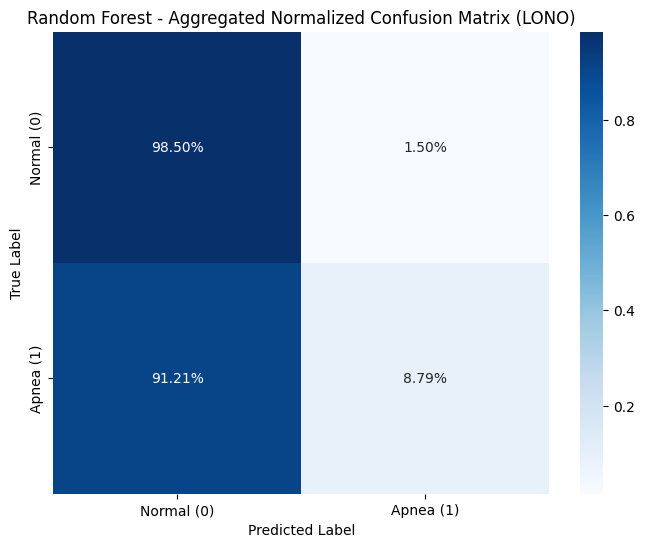

In [47]:
all_fold_predictions = []
all_fold_true_labels = []
all_fold_importances = [] 

# --- 3. Setup Leave-One-Night-Out cross-validator ---
logo = LeaveOneGroupOut()
n_folds = logo.get_n_splits(groups=groups)
# <-- CHANGE: Updated print statement
print(f"Starting Random Forest Leave-One-Night-Out cross-validation with {n_folds} folds...")
print("----------------------------------------------------\n")

# --- 4. Loop through each fold ---
for fold, (train_idx, test_idx) in enumerate(logo.split(X, y, groups)):
    
    test_night = np.unique(groups[test_idx])[0]
    print(f"--- FOLD {fold + 1}/{n_folds} ---")
    print(f"Testing on Night: {test_night}\n")

    # --- Split the data for this fold ---
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    # --- Balance the data using CLASS WEIGHTING (preferred for RF) ---
    # We will disable SMOTE and use the built-in class_weight parameter instead.
    print(f"  - Original training distribution: {Counter(y_train)}")
    # print("  - Using 'class_weight=balanced' to handle imbalance.")
    smote = SMOTE(random_state=RANDOM_STATE)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
    print(f"  - Resampled training distribution: {Counter(y_train_resampled)}")

    # --- Initialize and Train a NEW Random Forest model for this fold ---
    # <-- CHANGE: This is the main model swap
    print("  - Training Random Forest model...")
    model = RandomForestClassifier(
        n_estimators=500,          # Number of trees in the forest. Good starting point.
        max_depth=None,            # Let trees grow deep. RF is robust to overfitting.
        min_samples_leaf=1,        # The minimum number of samples required to be at a leaf node.
        # class_weight='balanced',   # Crucial for handling your imbalanced data.
        random_state=RANDOM_STATE,
        n_jobs=-1                  # Use all available CPU cores.
    )
    
    # We fit on the original (but flattened) data, NOT the SMOTE-resampled data.
    model.fit(X_train_resampled, y_train_resampled)
    print(f"  - Training complete.")
            
    # --- Evaluate the fold and store results ---
    fold_preds = model.predict(X_test)
    all_fold_predictions.extend(fold_preds)
    all_fold_true_labels.extend(y_test)

    # --- Capture and store feature importances ---
    # This works identically for RandomForestClassifier
    fold_importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': model.feature_importances_
    })
    all_fold_importances.append(fold_importance_df)

    print(f"  - Evaluation complete for fold {fold + 1}.\n")


# --- FINAL AGGREGATED EVALUATION ---
# <-- CHANGE: Updated print statements
print("\n====================================================")
print("Random Forest Leave-One-Night-Out Cross-Validation Complete.")
print("Aggregated Results Across All Folds:")
print("====================================================")

# --- Final Classification Report ---
print('\nAggregated Classification Report')
print('------------------------------')
class_names = ['Normal (0)', 'Apnea (1)']
print(classification_report(all_fold_true_labels, all_fold_predictions, target_names=class_names))

# --- Final Confusion Matrix ---
print('Aggregated Confusion Matrix')
print('---------------------------')
cm = confusion_matrix(all_fold_true_labels, all_fold_predictions)
# Normalization logic is the same
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_norm, annot=True, fmt='.2%', cmap='Blues', # Changed cmap for visual difference
    xticklabels=class_names, yticklabels=class_names
)
# <-- CHANGE: Updated plot title
plt.title('Random Forest - Aggregated Normalized Confusion Matrix (LONO)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()



Aggregated Feature Importances
------------------------------


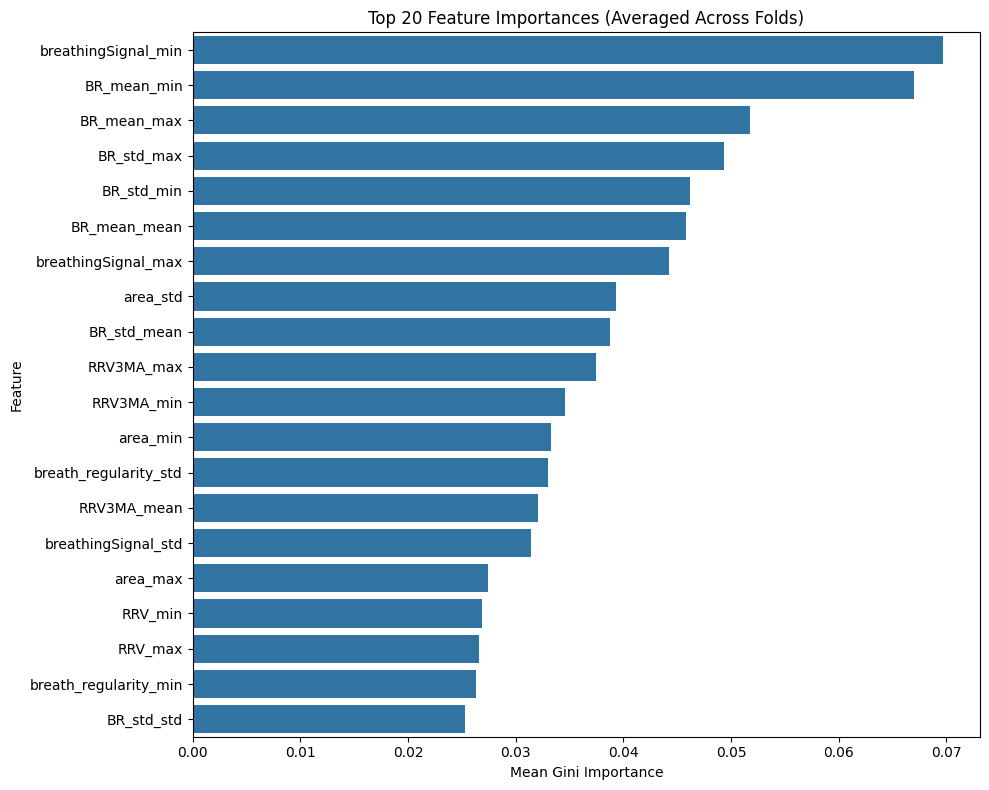


Ranked list of all feature importances:
feature
breathingSignal_min       0.069650
BR_mean_min               0.067030
BR_mean_max               0.051742
BR_std_max                0.049398
BR_std_min                0.046169
BR_mean_mean              0.045809
breathingSignal_max       0.044263
area_std                  0.039299
BR_std_mean               0.038768
RRV3MA_max                0.037485
RRV3MA_min                0.034600
area_min                  0.033317
breath_regularity_std     0.033029
RRV3MA_mean               0.032044
breathingSignal_std       0.031466
area_max                  0.027444
RRV_min                   0.026840
RRV_max                   0.026599
breath_regularity_min     0.026273
BR_std_std                0.025297
RRV3MA_std                0.023225
breath_regularity_max     0.022785
breath_regularity_mean    0.022330
area_mean                 0.022297
BR_mean_std               0.021056
RRV_mean                  0.020397
RRV_std                   0.017749
extrem

In [31]:
# --- Plotting the aggregated feature importances ---
print('\nAggregated Feature Importances')
print('------------------------------')

# 1. Concatenate all the importance dataframes from each fold
aggregated_importances = pd.concat(all_fold_importances)

# 2. Calculate the mean importance for each feature across all folds
mean_importances = aggregated_importances.groupby('feature')['importance'].mean().sort_values(ascending=False)

# 3. Plot the top 20 most important features
plt.figure(figsize=(10, 8))
sns.barplot(x=mean_importances.head(20), y=mean_importances.head(20).index)
plt.title('Top 20 Feature Importances (Averaged Across Folds)')
plt.xlabel('Mean Gini Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# You can also inspect the ranked list directly:
print("\nRanked list of all feature importances:")
print(mean_importances)